In [7]:
!pip install matplotlib
!pip install matplotlib numpy
import random
from matplotlib import pyplot as plt
import numpy as np
from enum import Enum


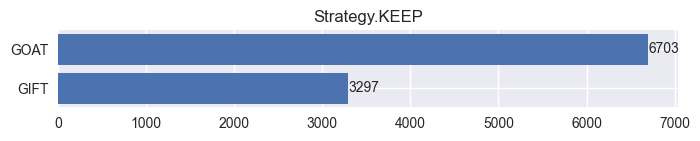

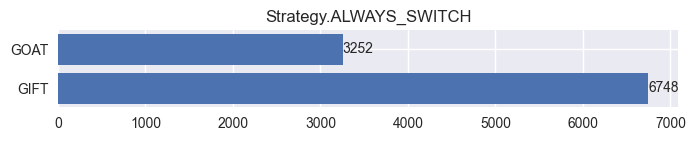

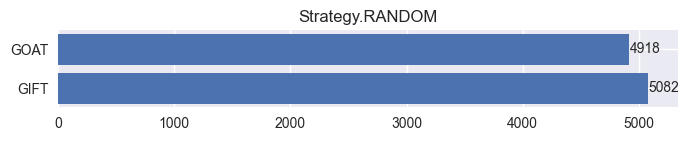

In [ ]:
import random
from matplotlib import pyplot as plt
import numpy as np
from enum import Enum
plt.style.use("seaborn-v0_8")  # 畫圖表

#三種策略：
#KEEP：不換門
#ALWAYS_SWITCH：一開始就決定換門
#RANDOM：隨機決定要不要換門
Strategy = Enum("Strategy", ["KEEP", "ALWAYS_SWITCH", "RANDOM"])

def monty_hall(strategy):
    #定義三扇門後面的東西
    behind_doors = ["GIFT", "GOAT", "GOAT"]
    #參賽者一開始隨機選一扇門
    step1 = random.choice(behind_doors)
    
    #打開第一扇門，先把參賽者選到的東西移除
    behind_doors.pop(behind_doors.index(step1))
    #不管如何 主持人會打開一扇裡面是羊的門
    behind_doors.pop(behind_doors.index("GOAT"))
    #這時候 behind_doors 裡面只剩下另一扇沒打開的門

    #根據策略決定要不要換門
    if strategy == Strategy.KEEP:
        pass
    elif strategy == Strategy.ALWAYS_SWITCH:
        step1, behind_doors[0] = behind_doors[0], step1
    elif strategy == Strategy.RANDOM:
        if random.choice(["SWAP", "NOSWAP"]) == "SWAP":
            step1, behind_doors[0] = behind_doors[0], step1
    #回傳最後拿到的是禮物還是羊
    return step1

#實驗次數----
N = 10000

#修改換策略-KEEP(保持不換:拿到禮物的機率=3312/10000=0.3312=1/3)----
strategy1 = Strategy.KEEP
#重複模擬 N 次
results1 = [monty_hall(strategy1) for _ in range(N)]
#結果畫出來
plt.figure(figsize=(8, 1))
plt.barh(*np.unique(results1, return_counts=True))
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title(strategy1)
plt.show()

#修改換策略-ALWAYS_SWITCH(換:拿到禮物的機率=6748/10000=0.6748=2/3)----
strategy2 = Strategy.ALWAYS_SWITCH
#重複模擬 N 次
results2 = [monty_hall(strategy2) for _ in range(N)]
#結果畫出來
plt.figure(figsize=(8, 1))
plt.barh(*np.unique(results2, return_counts=True))
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title(strategy2)
plt.show()

#修改換策略-RANDOM(隨機:拿到禮物的機率介於1/2~1/3之間 0.5 × 1/3 + 0.5 × 2/3 = 1/2=5082/10000=0.5082=1/2)----
strategy3 = Strategy.RANDOM
#重複模擬
results3 = [monty_hall(strategy3) for _ in range(N)]
#結果畫出來
plt.figure(figsize=(8, 1))
plt.barh(*np.unique(results3, return_counts=True))
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title(strategy3)
plt.show()

